# Example: `shugga` classification and metrics

This notebook runs the full `shugga` workflow for:

It uses the Python API directly so that the workflow is transparent and easy to modify.


In [4]:
import sys
from pathlib import Path
import xarray as xr
import numpy  as np
import pandas as pd
from IPython.display import Image, display
#####################################################################
# make sure this reflects the correct location of mawsons-chest repo
repo_root = Path.home() / "AFIM" / "src" / "mawsons-chest"
#####################################################################
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from shuga               import (RunSpec,
                                 ClassificationSpec,
                                 MetricsSpec,
                                 PlottingSpec,
                                 ObservationSpec,
                                 ShugaPaths)
from shuga.core.logging  import build_file_logger
from shuga.core          import report_sim_status
from shuga.io            import load_cice, load_classified, load_metrics
from shuga.classify      import CICEClassifier
from shuga.metrics.cice  import CICEMetrics
from shuga.plotting.cice import CICEPlotter

In [11]:
import importlib
import shuga.core.types as sht
import shuga.classify.cice as shc
import shuga.metrics.cice as shm
import shuga.plotting.cice as shp

importlib.reload(sht)
importlib.reload(shc)
importlib.reload(shm)
importlib.reload(shp)

RunSpec = sht.RunSpec
ClassificationSpec = sht.ClassificationSpec
MetricsSpec = sht.MetricsSpec
PlottingSpec = sht.PlottingSpec
ObservationSpec = sht.ObservationSpec
CICEClassifier = shc.CICEClassifier
CICEMetrics = shm.CICEMetrics
CICEPlotter = shp.CICEPlotter

# report on all experiments

In [5]:
archive_root = Path.home() / "AFIM_archive"
sim_names    = sorted(p.name for p in archive_root.iterdir() if p.is_dir() and (p.name.startswith("LD") or p.name == "NS-GIB"))
reports = {}
for sim_name in sim_names:
    print(f"\n{'='*100}\n{sim_name}\n{'='*100}")
    try:
        rep = report_sim_status(sim_name=sim_name)
        reports[sim_name] = rep
    except Exception as e:
        print(f"FAILED: {e}")


LD-linear-CL0p1
Simulation: LD-linear-CL0p1
Hemisphere: SH
Output root: /g/data/gv90/da1339/afim_output/LD-linear-CL0p1
Zarr root: /g/data/gv90/da1339/afim_output/LD-linear-CL0p1/zarr

CICE history store
  path: /g/data/gv90/da1339/afim_output/LD-linear-CL0p1/zarr/iceh_daily.zarr
  exists: True
  coverage: 1993-01-01 -> 2009-11-14 (203 monthly groups, n_time=None)
  static store: /g/data/gv90/da1339/afim_output/LD-linear-CL0p1/zarr/iceh_static.zarr
  static exists: True

Classifications
  1. binary-days [Tc]
     ice_type: FI
     ispd_thresh: 5.0e-4
     aice_thresh: 0.15
     binary-days: window=11, min_days=9
     class store: /g/data/gv90/da1339/afim_output/LD-linear-CL0p1/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/data.zarr
     coverage: 1993-01-01 -> 2008-12-31 (n_time=5844)
     metrics: no
  2. raw [Tc]
     ice_type: FI
     ispd_thresh: 5.0e-4
     aice_thresh: 0.15
     class store: /g/data/gv90/da1339/afim_output/LD-linear-CL0p1/zarr/SH/ispd_thresh_5.0e-4/FI/T

# setup shuga for a simulation

In [5]:
run          = RunSpec(sim_name="LD-linear-CL0p1", start_date="1993-01-01", end_date="1999-12-31")
classify     = ClassificationSpec(ice_type="FI", grid_type="Tc")
metrics_spec = MetricsSpec()
plotting     = PlottingSpec(fig_size=20,)
observations = ObservationSpec(seaice_root="/g/data/gv90/da1339/SeaIce")
paths        = ShugaPaths(run=run, classify=classify)
logger       = build_file_logger("shugga.example", paths.logs_root_path / "notebooks" / "LD-waves-exp01_1993_example.log")
logger.info("Notebook logger ready")
shuga_plot   = CICEPlotter(run          = run,
                           classify     = classify,
                           metrics      = metrics_spec,
                           plotting     = plotting,
                           observations = observations,
                           paths        = paths,
                           logger       = logger)

2026-04-10 13:50:04,071 - INFO - [shugga.example.<module>:8] Notebook logger ready


## Test loading

In [3]:
cice    = load_cice(run, dt0_str="2001-01-01", dtN_str="2001-12-31")

load_cice() called with variables=None; loading all variables from iceh_daily.zarr can be very memory-intensive for long date ranges.
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
INFO:shuga.io.zarr_loading:	slicing the time
INFO:shuga.io.zarr_loading:	appended to dataset list
INFO:shuga.io.zarr_loading:	group 2001-02 with chunks {'time': 31}
INFO:shuga.io.zarr_loading:	slicing the time
INFO:shuga.io.zarr_loading:	appended to dataset list
INFO:shuga.io.zarr_loading:	group 2001-03 with chunks {'time': 31}
INFO:shuga.io.zarr_loading:	slicing the time
INFO:shuga.io.zarr_loading:	appended to dataset list
INFO:shuga.io.zarr_loading:	group 2001-04 with chunks {'time': 31}
INFO:shuga.io.zarr_loadi

In [4]:
cice

<xarray.Dataset> Size: 107GB
Dimensions:   (time: 365, nj: 1080, ni: 1440, nc: 5, nkaer: 5)
Coordinates:
  * time      (time) datetime64[ns] 3kB 2001-01-01 2001-01-02 ... 2001-12-31
    NLON      (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    TLON      (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    ELAT      (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    TLAT      (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    ULON      (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    NLAT      (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    ULAT      (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    ELON      (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
Dimensions without coordinates: nj, ni, nc, nkaer
Data variables: (12/70)
    strairyE  (time, nj, ni) float32 2GB dask.array<chunksize=(31, 1080, 720), meta=np.ndarray>
    sig1      (time, nj, ni) float32 2GB dask.array<chunksize=(31, 1080, 720), meta=np.ndarray>
    daidtt    (time, nj, ni) float32 2GB dask.array<chunksize=(31, 1080, 720), meta=np.ndarray>
    KuyN      (time, nj, ni) float32 2GB dask.array<chunksize=(31, 1080, 720), meta=np.ndarray>
    uocn      (time, nj, ni) float32 2GB dask.array<chunksize=(31, 1080, 720), meta=np.ndarray>
    vocn      (time, nj, ni) float32 2GB dask.array<chunksize=(31, 1080, 720), meta=np.ndarray>
    ...        ...
    uarea     (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    dxn       (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    tarea     (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    umask     (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    dyu       (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
    ANGLE     (nj, ni) float32 6MB dask.array<chunksize=(1080, 720), meta=np.ndarray>
Attributes: (12/13)
    title:               sea ice model output for CICE
    contents:            Diagnostic and Prognostic Variables
    source:              CICE Sea Ice Model, CICE_6.6.2
    comment:             This year has 365 days
    comment2:            File written on model date 20010102
    comment3:            seconds elapsed into model date:      0
    ...                  ...
    time_axis_position:  end
    Conventions:         CF-1.8
    external_variables:   VGRDi VGRDs VGRDb NFSD
    history:             This dataset was created on 2026-03-28 at 23:58:33.8
    date_created:        2026-03-28 23:58:33.8
    io_flavor:           io_netcdf cdf1

In [14]:
FI_mask = load_classified(run, classification='binary-days')
mets    = load_metrics(run, classification='binary-days')

INFO:shuga.io.zarr_loading:resolving run context: sim_name, date start/stop, hemisphere, etc.
INFO:shuga.io.zarr_loading:resolving classification context
INFO:shuga.io.zarr_loading:building paths
INFO:shuga.io.zarr_loading:Opening classified store for LD-static-Cs2p5e-4 [Tc/binary-days]: /g/data/gv90/da1339/afim_output/LD-static-Cs2p5e-4/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/data.zarr
INFO:shuga.io.zarr_loading:resolving run context: sim_name, date start/stop, hemisphere, etc.
INFO:shuga.io.zarr_loading:resolving classification context
INFO:shuga.io.zarr_loading:building paths
INFO:shuga.io.zarr_loading:Opening metrics store for LD-static-Cs2p5e-4 [Tc/binary-days]: /g/data/gv90/da1339/afim_output/LD-static-Cs2p5e-4/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr


In [16]:
mets

<xarray.Dataset> Size: 6MB
Dimensions:                 (time: 730, region: 8, nj: 1080, ni: 1440)
Coordinates:
  * time                    (time) datetime64[ns] 6kB 1993-01-01 ... 1994-12-31
  * region                  (region) object 64B 'DML' 'WIO' 'EIO' ... 'BS' 'WS'
Dimensions without coordinates: nj, ni
Data variables: (12/25)
    FIT_doy_max_std         float64 8B ...
    ever_winter_area        float32 4B ...
    FIT_min_std             float64 8B ...
    FIT_doy_max_mean        float64 8B ...
    FIV                     (time) float32 3kB ...
    FIT_min_mean            float64 8B ...
    ...                      ...
    FIT                     (time) float32 3kB ...
    FIT_doy_min_mean        float64 8B ...
    FIA_max_mean            float64 8B ...
    FIP                     (nj, ni) float32 6MB ...
    FIA_doy_max_std         float64 8B ...
    persistent_winter_area  float32 4B ...
Attributes:
    sim_name:    LD-static-Cs2p5e-4
    start_date:  1993-01-01
    end_date:    2010-12-31
    hemisphere:  SH
    ice_type:    FI
    grid_type:   Tc
    method:      binary-days

## 1. Run classification

This computes:

- raw daily FI mask
- binary-days FI mask
- rolling-mean FI mask


In [4]:
classifier    = CICEClassifier(run=run, classify=classify, paths=paths, logger=logger)
class_outputs = classifier.run_methods(overwrite=False)

2026-04-07 16:48:09,709 - INFO - Resolved classification root: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/SH/ispd_thresh_5.0e-4/FI/Tc
2026-04-07 16:48:09,712 - INFO - Classification speed reconstruction mode(s): Tc
2026-04-07 16:48:09,713 - INFO - Resolved CICE store: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/iceh_daily.zarr
2026-04-07 16:48:09,715 - INFO - Resolved static store: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/iceh_static.zarr
2026-04-07 16:48:09,739 - INFO - Opening grouped monthly Zarr between 1993-01-01 and 1993-12-31 (12 groups)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
2026-04-07 16:48:17,598 - INFO - Merging static variables from: /g/data/gv

## 2. Run metrics

In [5]:
classify = ClassificationSpec(methods = ("binary-days", "rolling-mean"))
metrics  = CICEMetrics(run=run, classify=classify, metrics=metrics_spec, paths=paths, logger=logger)
for method in classify.methods:
    metrics.compute_metrics(method, overwrite=False)

2026-04-07 16:48:25,608 - INFO - Resolved class store for binary-days: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/data.zarr
2026-04-07 16:48:25,610 - INFO - Resolved metrics store for binary-days: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
2026-04-07 16:48:25,611 - INFO - Resolved CICE store: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/iceh_daily.zarr
2026-04-07 16:48:25,613 - INFO - Resolved static store: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/iceh_static.zarr
2026-04-07 16:48:25,637 - INFO - Opening grouped monthly Zarr between 1993-01-01 and 1993-12-31 (12 groups)
2026-04-07 16:48:26,884 - INFO - Merging static variables from: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/iceh_static.zarr
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encou

## 3. Load computed metrics quickly

In [6]:
bin_mets  = metrics.load_metrics("binary-days")
roll_mets = metrics.load_metrics("rolling-mean")
print(bin_mets['FIA_by_region'])

<xarray.DataArray 'FIA_by_region' (time: 365, region: 8)> Size: 12kB
dask.array<open_dataset-FIA_by_region, shape=(365, 8), dtype=float32, chunksize=(31, 8), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1993-01-01 1993-01-02 ... 1993-12-31
  * region   (region) object 64B 'DML' 'WIO' 'EIO' 'Aus' 'VOL' 'AS' 'BS' 'WS'
Attributes:
    long_name:  Fast Ice Area by Antarctic sector
    units:      10^3 km^2


## 4. Inspect time series and regional metrics

In [ ]:
ds          = metrics.load_cice(["TLON", "TLAT", "tarea"])
lon, lat    = metrics._detect_lonlat(ds)
area        = metrics._ensure_2d_static(ds["tarea"])
region_mask = metrics._region_mask(area, lon, lat)
print("region cell counts")
print(region_mask.sum(dim=("nj", "ni")).compute())
print("region domain area [10^3 km^2]")
print((region_mask.astype("float32") * area).sum(dim=("nj", "ni")).compute() / 1e9)
fi_any = metrics.load_classification("binary-days").any("time")
lon_fi = lon.where(fi_any)
lat_fi = lat.where(fi_any)
print("FI lon range:", float(lon_fi.min().compute()), float(lon_fi.max().compute()))
print("FI lat range:", float(lat_fi.min().compute()), float(lat_fi.max().compute()))
print(bin_mets["FIA_by_region"].max("time").compute())
print(bin_mets["FIT_by_region"].max("time").compute())
print(bin_mets["FIA_by_region"].sel(time="1993-09-28").compute())
print(bin_mets["FIT_by_region"].sel(time="1993-09-28").compute())

## 5. Plot FIP, FIA, and FIT with PyGMT

These methods write figures into the default graphics tree under `/g/data/[PROJECT]/[USER]/GRAPHICAL/AFIM/...`.


### FIP

In [3]:
shuga_plot.plot_fip(method="binary-days", colorbar_position = "JMB+w8c/0.4c+o0.8c/0c", colorbar_xlabel="Fast Ice Persistence", grid_style="c0.125c")

2026-04-10 08:23:11,450 - INFO - [shugga.example.plot_fip:359] plot_fip: loading precomputed FIP from metrics store for LD-static-Cs2p5e-4 (binary-days)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
2026-04-10 08:23:17,585 - INFO - [shugga.example.plot_fip:488] creating figure: /g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/DML/FIP/1993-01-01_2010-12-31_LD-static-Cs2p5e-4_FIP_binary_days.png
2026-04-10 08:23:18,984 - INFO - [shugga.example.plot_fip:537] 	saved
2026-04-10 08:23:19,160 - INFO - [shugga.example.plot_fip:488] creating figure: /g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/WIO/FIP/1993-01-01_2010-12-31_LD-static-Cs2p5e-4_FIP_binary_days.png
2026-04-10 08:23:19,789 

{'DML': '/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/DML/FIP/1993-01-01_2010-12-31_LD-static-Cs2p5e-4_FIP_binary_days.png',
 'WIO': '/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/WIO/FIP/1993-01-01_2010-12-31_LD-static-Cs2p5e-4_FIP_binary_days.png',
 'EIO': '/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/EIO/FIP/1993-01-01_2010-12-31_LD-static-Cs2p5e-4_FIP_binary_days.png',
 'Aus': '/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/Aus/FIP/1993-01-01_2010-12-31_LD-static-Cs2p5e-4_FIP_binary_days.png',
 'VOL': '/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/VOL/FIP/1993-01-01_2010-12-31_LD-static-Cs2p5e-4_FIP_binary_days.png',
 'AS': '/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/AS/FIP/1993-01-01_2010-12-31_LD-static-Cs2p5e-4_FIP_binary_days.png',
 'BS': '/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/BS/FIP/1993-01-01_2010-12-31_LD-static-Cs2p5e-4_FIP_binary_days.png',
 'WS': '/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/WS/F

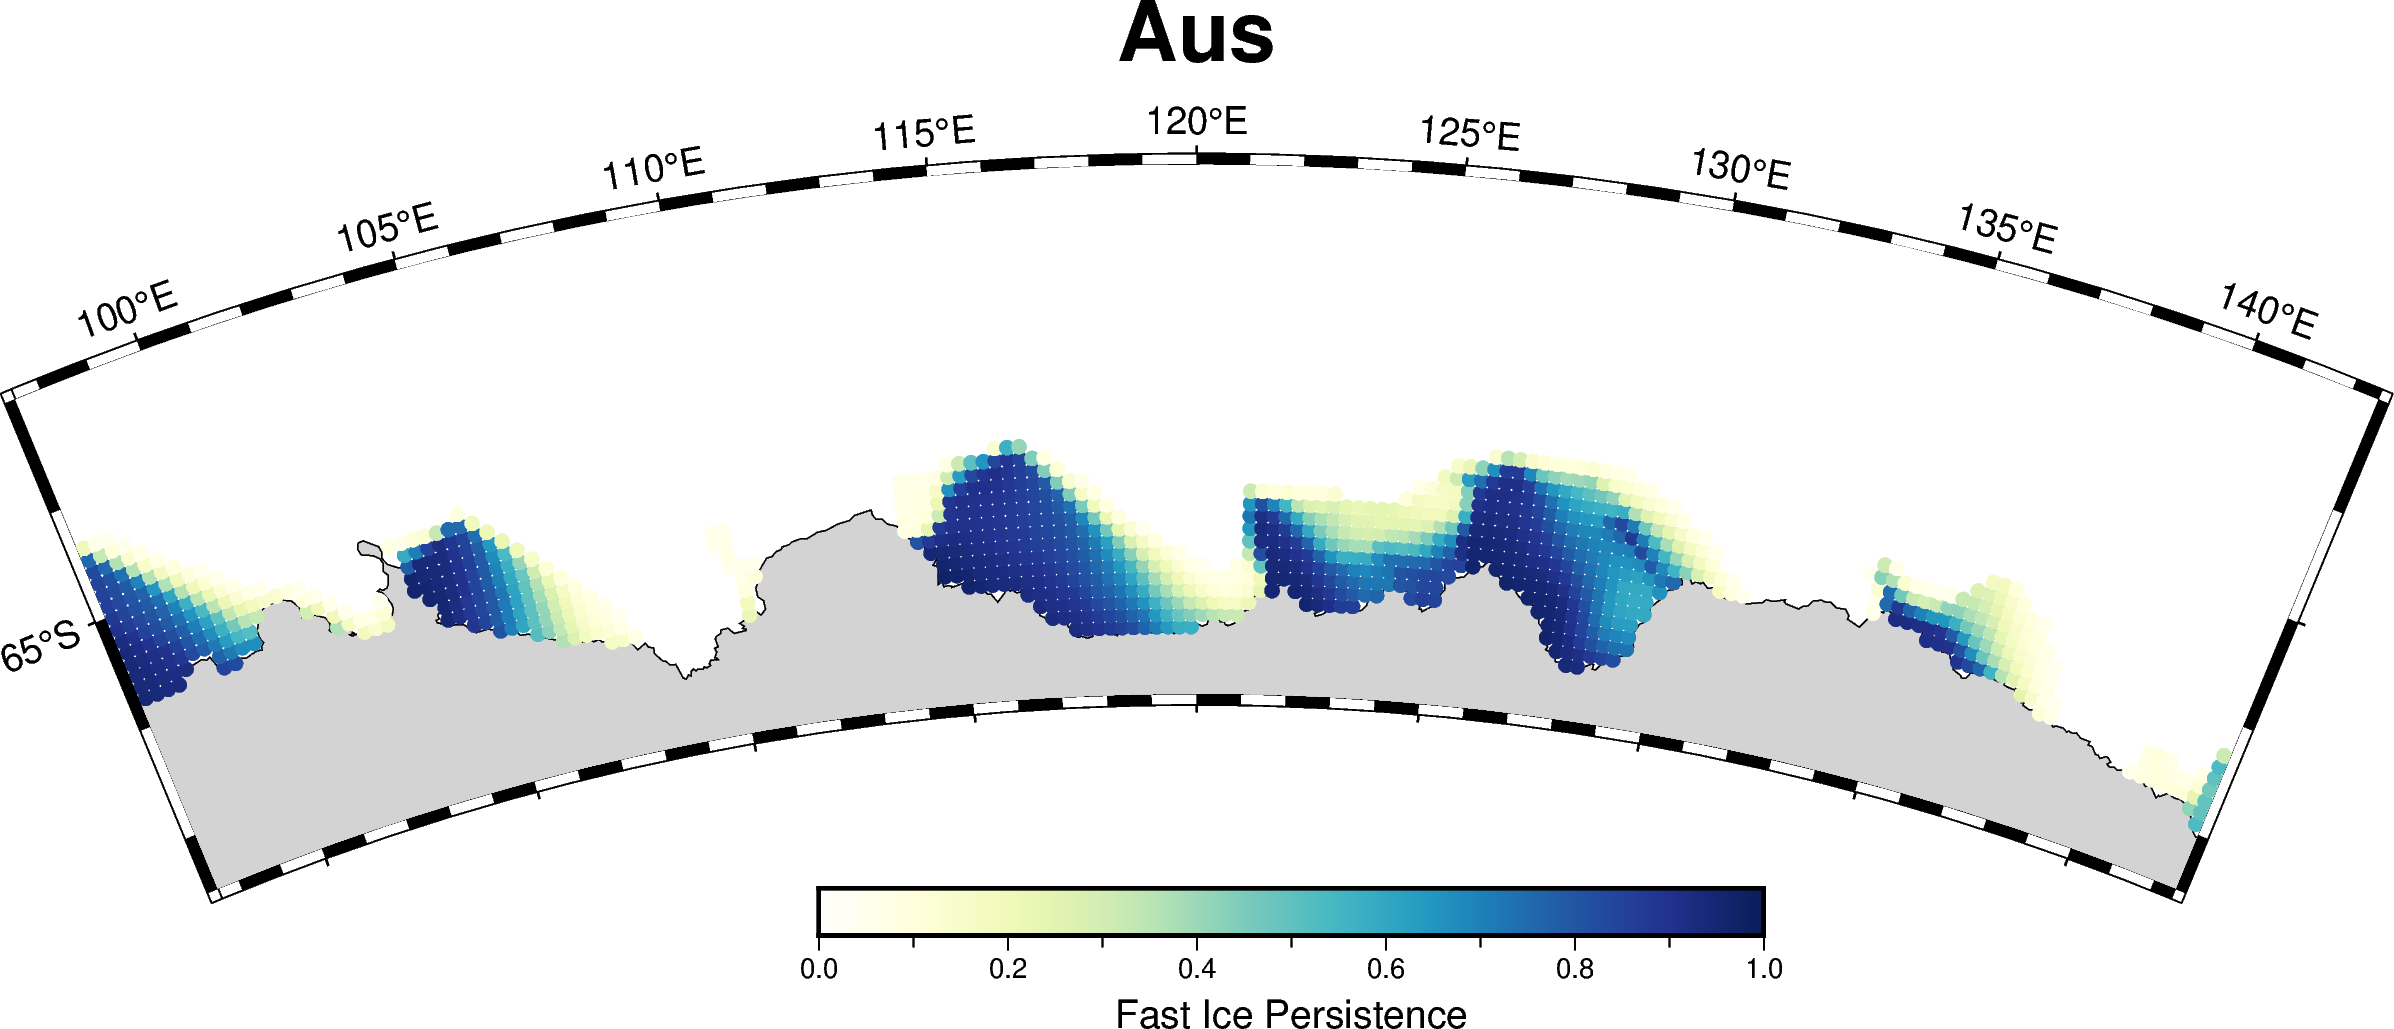

In [4]:
from IPython.display import Image, display
png = "/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/Aus/FIP/1993-01-01_2010-12-31_LD-static-Cs2p5e-4_FIP_binary_days.png"
display(Image(filename=png))

### timeseries one simulation (FIA/FIT/SIA/SIT/etc.)

In [3]:
shuga_plot.plot_timeseries(method="binary-days", variable="FIA", add_f2020=True, f2020_mode="overlap")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
INFO:shuga.io.zarr_loading:raw metrics ds: sizes={'time': 2556, 'nj': 1080, 'ni': 1440, 'region': 8} time=1993-01-01T00:00:00.000000000 -> 1999-12-31T00:00:00.000000000
INFO:shuga.io.zarr_loading:after hemisphere mask: sizes={'time': 2556, 'nj': 1080, 'ni': 1440, 'region': 8}


NameError: name 'dt0_req' is not defined

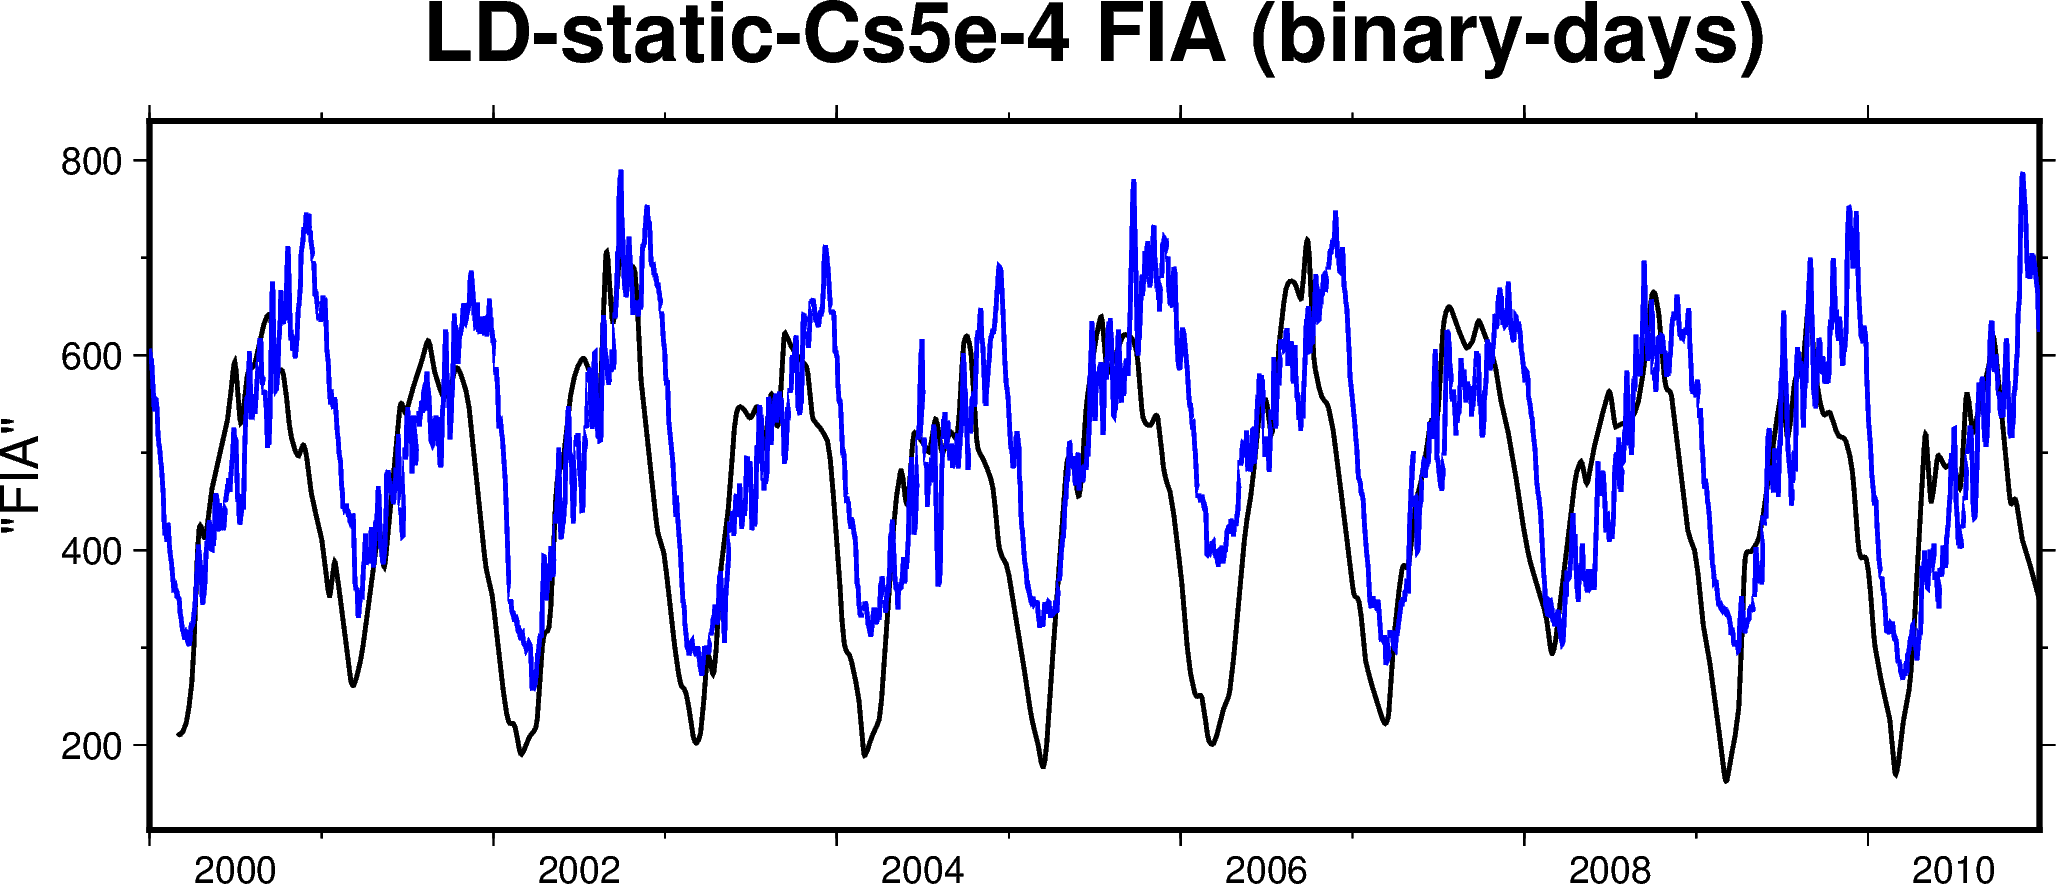

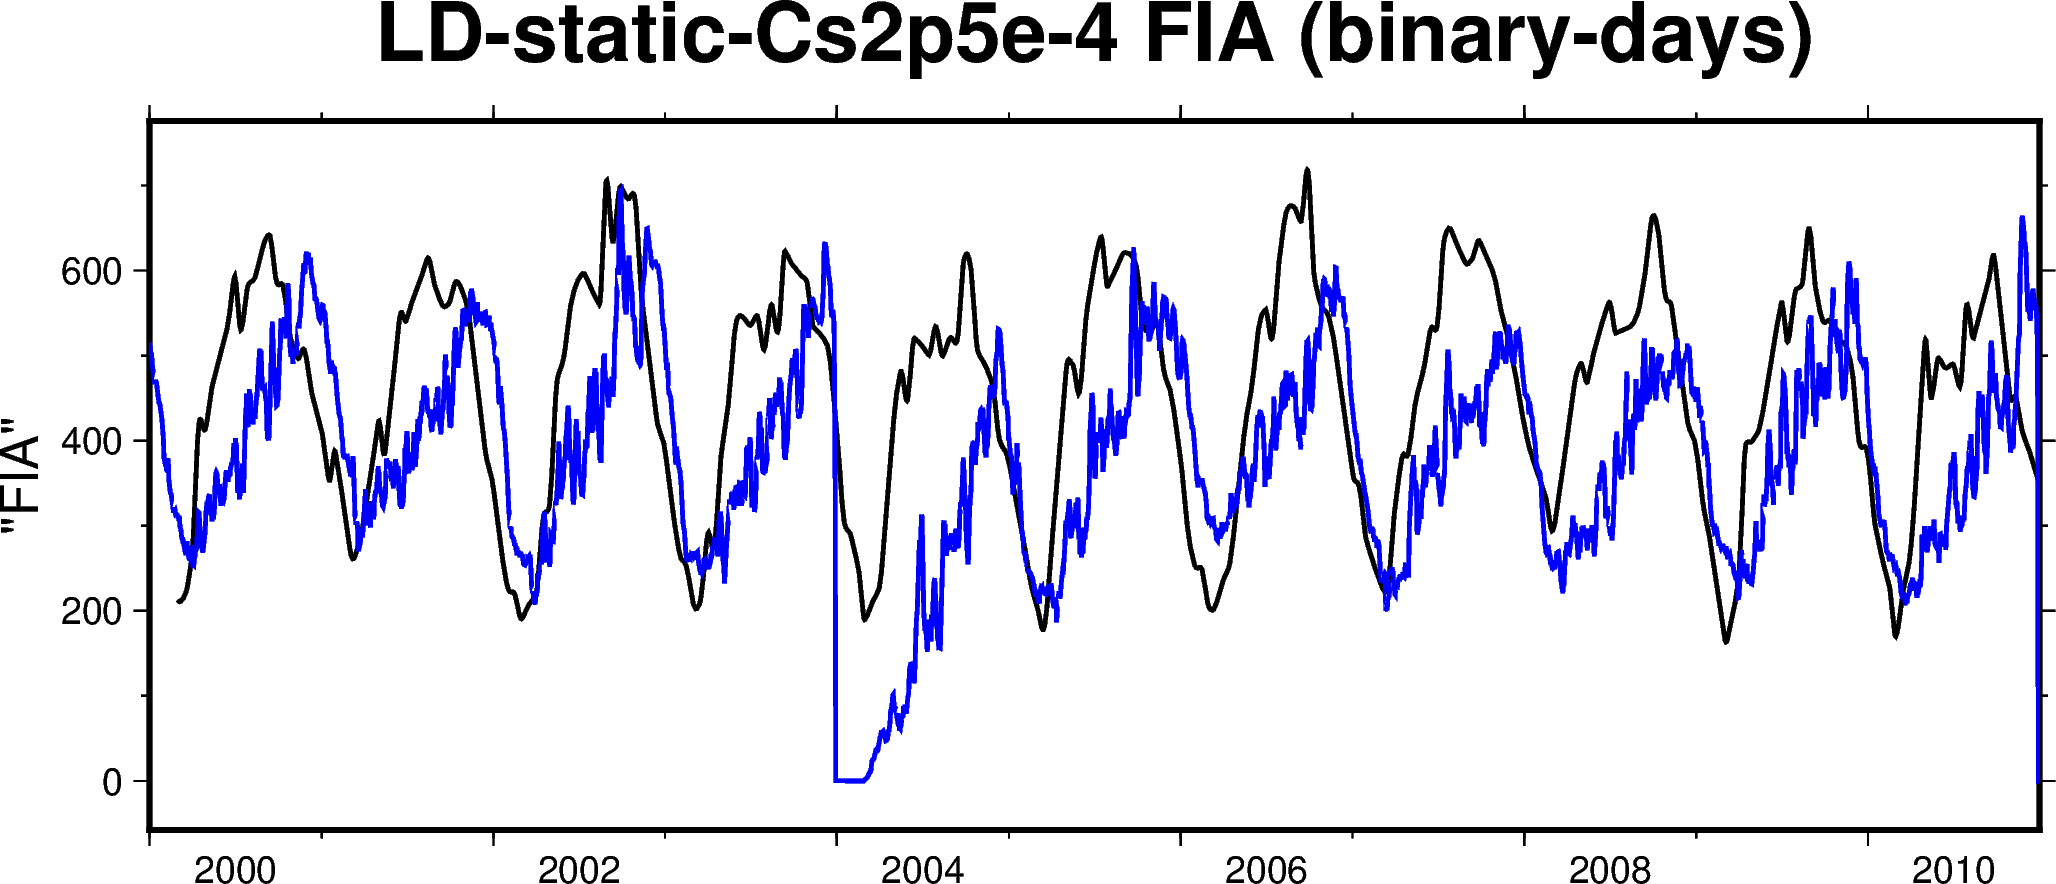

In [8]:
png = '/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs5e-4/timeseries/2000-01-01_2010-12-31_LD-static-Cs5e-4_FIA_total_binary_days.png'
display(Image(filename=png))
png = '/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-static-Cs2p5e-4/timeseries/2000-01-01_2010-12-31_LD-static-Cs2p5e-4_FIA_total_binary_days.png'
display(Image(filename=png))

### timeseries for multiple simulation (FIA/FIT/SIA/SIT/etc.)

In [10]:
shuga_plot.plot_timeseries_multi(variable    = "FIA",
                                 method      = "binary-days",
                                 dt0_str     = "1993-01-01",
                                 dtN_str     = "1993-12-31",
                                 simulations = ["LD-static-Cs2p5e-4", "LD-waves-exp01"],
                                 add_f2020   = True,
                                 f2020_mode  = "climatology",
                                 legend_position = "JTL+jTL+o0.2c",
                                 show        = True)

INFO:shuga.io.zarr_loading:resolving run context: sim_name, date start/stop, hemisphere, etc.
INFO:shuga.io.zarr_loading:resolving classification context
INFO:shuga.io.zarr_loading:building paths
INFO:shuga.io.zarr_loading:Opening metrics store for LD-static-Cs2p5e-4 [Tc/binary-days]: /g/data/gv90/da1339/afim_output/LD-static-Cs2p5e-4/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
2026-04-10 09:30:06,717 - INFO - [shugga.example.plot_timeseries_multi:879] Loaded FIA for LD-static-Cs2p5e-4 using grid_type=Tc
INFO:shuga.io.zarr_loading:resolving run context: sim_name, date start/stop, hemisphere, etc.
INFO:shuga.io.zarr_loading:resolving classification context
INFO:shuga.io.zarr_loading:building paths
INFO:shuga.io.zarr_loading:Opening metrics store for LD-waves-exp01 [Tc/binary-days]: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
2026-04-10 09:30:07,753 - INFO - [shugga.example.plot_timeseries_multi:879]

GMTCLibError: Module 'basemap' failed with status code 72:
basemap [ERROR]: Option -B parsing failure. Correct syntax:
basemap [ERROR]: Offending option -BWSen

### split hemisphere

In [25]:
aice_fig = shuga_plot.plot_var_split_hemisphere(
    variable="aice",
    date_str="1993-09-28",
    add_nsidc_south=True,
    add_nsidc_north=False,
    output_path="/g/data/gv90/da1339/GRAPHICAL/AFIM/LD-waves-exp01/aice/1993-09-28.png",
)
print(aice_fig)

2026-04-06 10:34:03,404 - INFO - Resolved CICE store: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/iceh_daily.zarr
2026-04-06 10:34:03,406 - INFO - Resolved static store: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/iceh_static.zarr
2026-04-06 10:34:03,427 - INFO - Opening grouped monthly Zarr between 1993-01-01 and 1993-12-31 (12 groups)
2026-04-06 10:34:04,737 - INFO - Merging static variables from: /g/data/gv90/da1339/afim_output/LD-waves-exp01/zarr/iceh_static.zarr
subplot [ERROR]: No subplot information file found!
subplot [ERROR]: Unable to open file /home/581/da1339/.gmt/sessions/gmt_session.2405555/gmt.subplotorder.7!


GMTCLibError: Module 'subplot' failed with status code 15:
subplot [ERROR]: No subplot information file found!
subplot [ERROR]: Unable to open file /home/581/da1339/.gmt/sessions/gmt_session.2405555/gmt.subplotorder.7!

In [26]:
fi_mask_fig = shuga_plot.plot_var_split_hemisphere(
    variable="FI_mask",
    date_str="1993-09-28",
    method="binary-days",
    add_nsidc_south=False,
    add_nsidc_north=False,
)
print(fi_mask_fig)

subplot [ERROR]: No subplot information file found!
subplot [ERROR]: Unable to open file /home/581/da1339/.gmt/sessions/gmt_session.2405555/gmt.subplotorder.8!


GMTCLibError: Module 'subplot' failed with status code 15:
subplot [ERROR]: No subplot information file found!
subplot [ERROR]: Unable to open file /home/581/da1339/.gmt/sessions/gmt_session.2405555/gmt.subplotorder.8!

In [ ]:
triptych_path = plotter.plot_triptych(
    left_da=SO_waves["wave_sig_ht"].isel(time=200),
    middle_da=FId.isel(time=200),
    right_da=(SO_waves["F2E"].isel(time=0)**2 + SO_waves["F2N"].isel(time=0)**2) ** 0.5,
    left_overlay=FI_waves["FI_mask"].isel(time=200),
    right_overlay=FI_static["FI_mask"].isel(time=200),
    region=[30, 80, -71, -64],
    fig_size=20,
    left_title="waves",
    middle_title="waves - no_waves",
    right_title="no_waves",
    middle_cmap="shuga/cpt/FIP.cpt",
)
print(triptych_path)

## 6. Regional example

Use one of the eight Antarctic sectors: `DML`, `WIO`, `EIO`, `Aus`, `VOL`, `AS`, `BS`, `WS`.


In [ ]:
regional_fia_path = metrics.plot_timeseries("FIA", "binary-days", region="WIO")
regional_fit_path = metrics.plot_timeseries("FIT", "binary-days", region="WIO")

regional_fia_path, regional_fit_path

## 7. Notes

- `load_metrics("raw")`, `load_metrics("binary-days")`, and `load_metrics("rolling-mean")` let you reopen products without recomputing them.
- Classification stores live alongside metrics stores under the same method directories.
- The notebook uses the exact same shared `ShuggaPaths` rules as the PBS and CLI workflows.
